CREDIT RISK 

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
pd.set_option('display.max_columns', None)

In [55]:
sns.set_style('whitegrid')

In [56]:
df=pd.read_csv('german_credit_data.csv')

In [57]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [58]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [59]:
df.shape

(1000, 11)

In [60]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [62]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [63]:
df.describe(include='all')

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [64]:
df["Job"].unique()

array([2, 1, 3, 0])

In [65]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df=df.dropna().reset_index(drop=True)

In [68]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [69]:
df.drop(columns=["Unnamed: 0"], inplace=True)

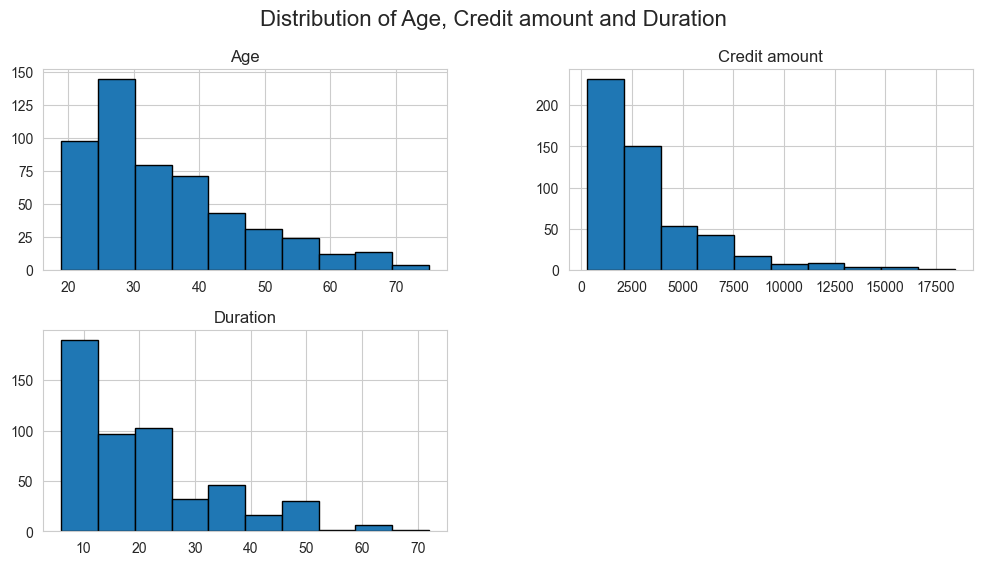

In [70]:
df[["Age",'Credit amount','Duration']].hist(bins=10,edgecolor='black',figsize=(12,6))
plt.suptitle('Distribution of Age, Credit amount and Duration', fontsize=16)
plt.show()

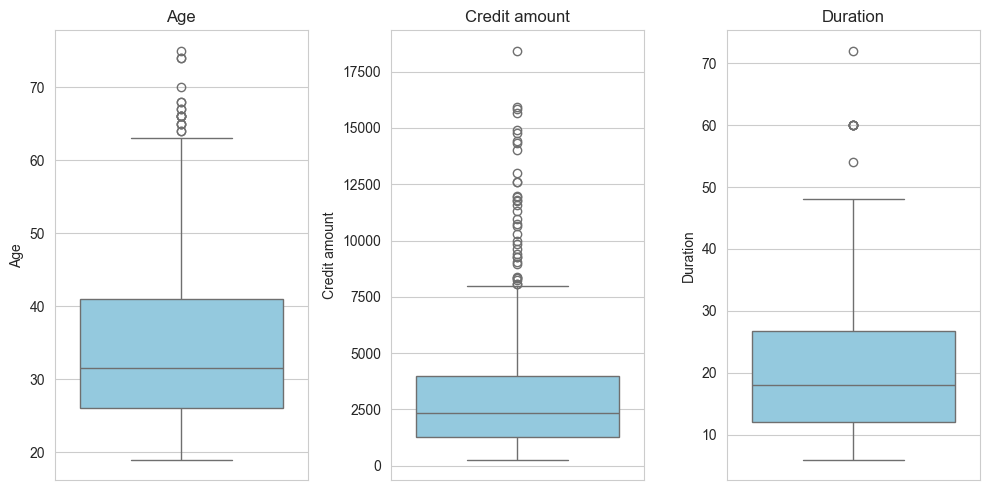

In [71]:
plt.figure(figsize=(10,5))
for i ,col in enumerate(['Age','Credit amount','Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [72]:
df.query("Duration>=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [73]:
categorical_cols=["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

C:\Users\Hafsa Naz\AppData\Local\Temp\ipykernel_15968\1729860423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col, palette="Set2",order=df[col].value_counts().index)
C:\Users\Hafsa Naz\AppData\Local\Temp\ipykernel_15968\1729860423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col, palette="Set2",order=df[col].value_counts().index)
C:\Users\Hafsa Naz\AppData\Local\Temp\ipykernel_15968\1729860423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col, palette="Set2",order=df[col].value_counts()

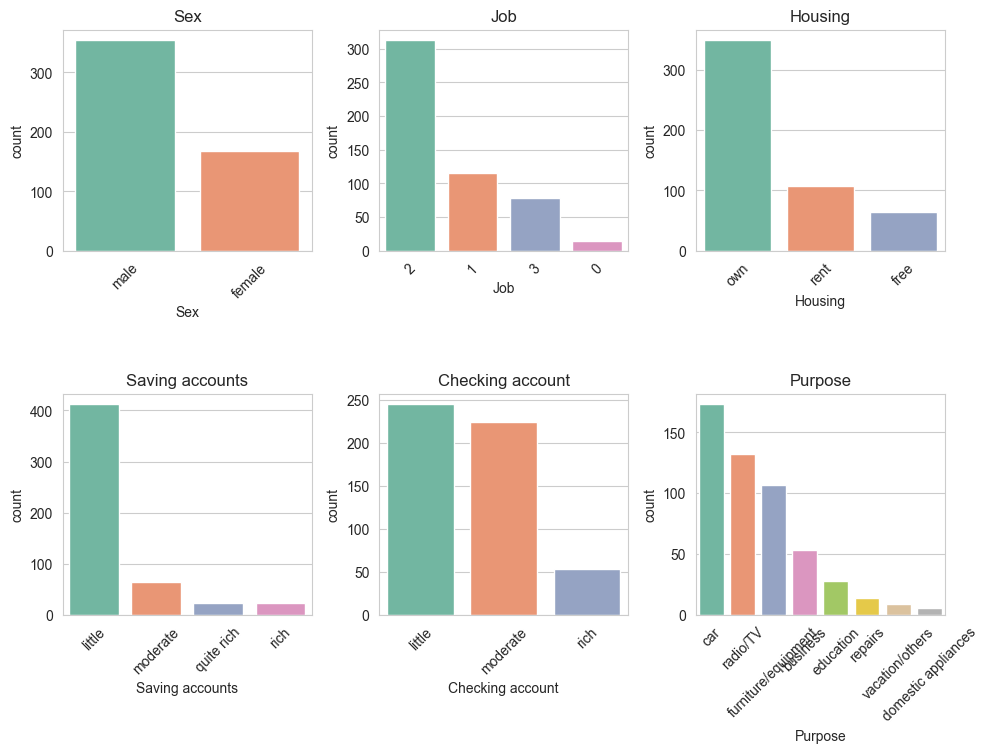

In [74]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
   plt.subplot(3,3,i+1)
   sns.countplot(data=df,x=col, palette="Set2",order=df[col].value_counts().index)
   plt.title(col)
   plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
corr=df[['Age','Job','Credit amount','Duration']].corr()

In [76]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


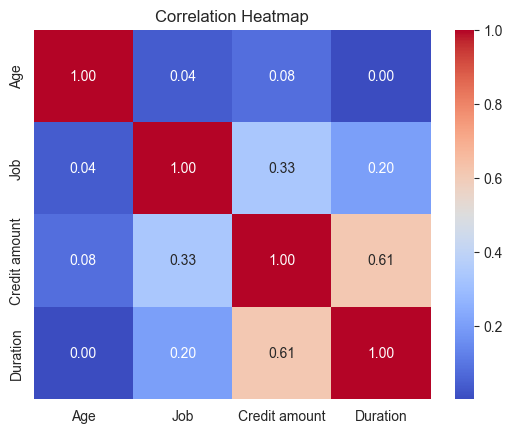

In [77]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')    
plt.show()

In [78]:
df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [79]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [80]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns="Purpose")


Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


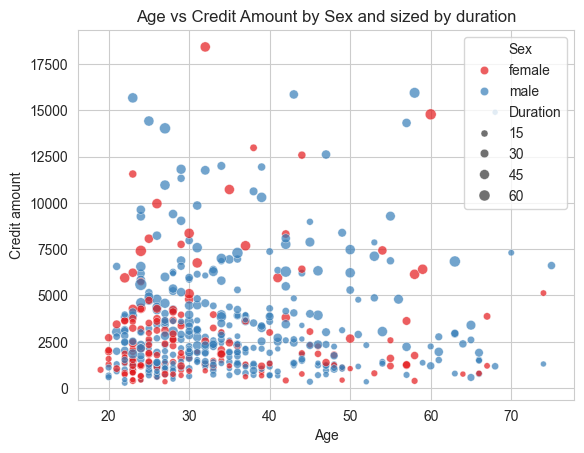

In [81]:
sns.scatterplot(data=df, x='Age', y='Credit amount', hue='Sex',size="Duration",alpha=0.7,palette="Set1")
plt.title('Age vs Credit Amount by Sex and sized by duration')
plt.show()

C:\Users\Hafsa Naz\AppData\Local\Temp\ipykernel_15968\3759673049.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette="Set2")


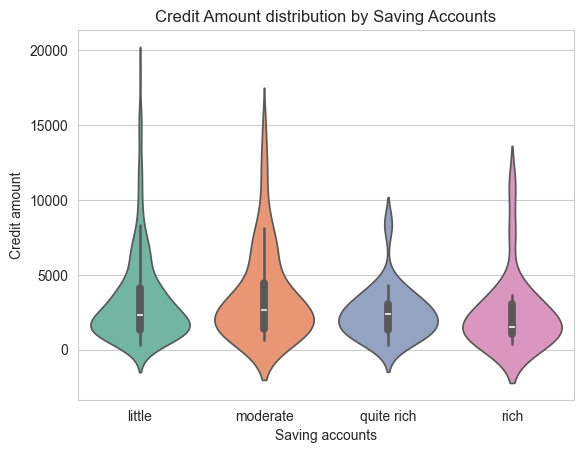

In [82]:
sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette="Set2")
plt.title('Credit Amount distribution by Saving Accounts')
plt.show()

In [83]:
df['Risk'].value_counts(normalize=True)*100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\Hafsa Naz\AppData\Local\Temp\ipykernel_15968\868652921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y = col, palette="Set2")
C:\Users\Hafsa Naz\AppData\Local\Temp\ipykernel_15968\868652921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y = col, palette="Set2")
C:\Users\Hafsa Naz\AppData\Local\Temp\ipykernel_15968\868652921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y = col, palette="Set2")


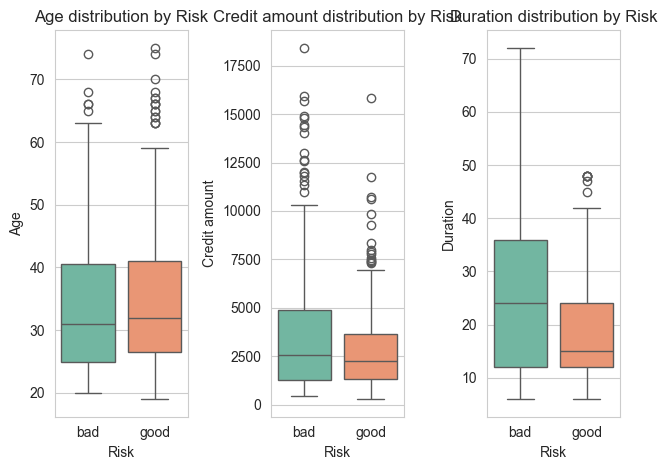

In [84]:
for i,col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x="Risk", y = col, palette="Set2")
    plt.title(f'{col} distribution by Risk')
plt.tight_layout()
plt.show()

In [85]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


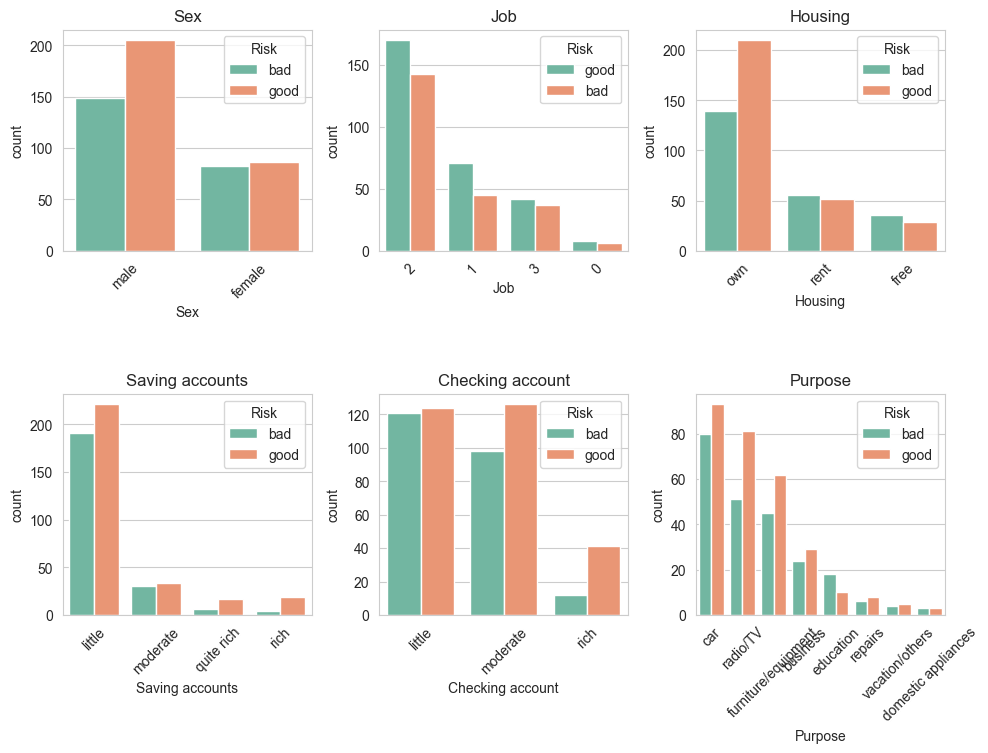

In [86]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
   plt.subplot(3,3,i+1)
   sns.countplot(data=df,x=col, hue="Risk", palette="Set2",order=df[col].value_counts().index)
   plt.title(col)
   plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
features=["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]
target="Risk"

In [88]:
df_model=df[features+[target]]

In [89]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


In [90]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [91]:
cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")

C:\Users\Hafsa Naz\AppData\Local\Temp\ipykernel_15968\2637306855.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")


In [92]:
le_dict={}

In [93]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [102]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le

# Save the label encoders
    joblib.dump(le,f"{col}_label_encoder.pkl")

In [95]:
le_target=LabelEncoder()

In [96]:
target

'Risk'

In [97]:
df_model[target]=le_target.fit_transform(df_model[target])

In [98]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [101]:
joblib.dump(le_target,f"{target}_label_encoder.pkl")

['Risk_label_encoder.pkl']

In [103]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [104]:
from sklearn.model_selection import train_test_split


In [105]:
x=df_model.drop(columns=[target])
y=df_model[target]

In [106]:
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [107]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [108]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=1)

In [109]:
x_train.shape

(417, 8)

In [110]:
y_train.shape

(417,)

In [111]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import GridSearchCV

In [112]:
def train_model(model, param_grid, x_train,y_train,x_test,y_test):
    grid=GridSearchCV(model, param_grid, cv=5, scoring='accuracy',n_jobs=-1)
    grid.fit(x_train,y_train)
    best_model=grid.best_estimator_
    y_pred=best_model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    return best_model, acc, grid.best_params_

In [113]:
dt=DecisionTreeClassifier(random_state=1,class_weight='balanced')
dt_param_grid={
    'max_depth':[3,5,7,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}



In [114]:
best_dt, dt_acc, dt_best_params=train_model(dt, dt_param_grid, x_train,y_train,x_test,y_test)

In [115]:
print("Best Decision Tree Accuracy:", dt_acc)
print("Best Decision Tree Parameters:", dt_best_params)

Best Decision Tree Accuracy: 0.580952380952381
Best Decision Tree Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [118]:
rf=RandomForestClassifier(random_state=1,class_weight='balanced', n_jobs=-1)


In [119]:
rf_param_grid={
    'n_estimators':[100,200],       
    'max_depth':[3,5,7,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [120]:
best_rf,acc_rf,params_rf=train_model(rf, rf_param_grid, x_train,y_train,x_test,y_test)

In [123]:
print("Best Random Forest Accuracy:", acc_rf)
print("Best Random Forest Parameters:", params_rf)

Best Random Forest Accuracy: 0.6190476190476191
Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [122]:
et=ExtraTreesClassifier(random_state=1,class_weight='balanced', n_jobs=-1)

In [124]:
et_param_grid={
    'n_estimators':[100,200],
    'max_depth':[3,5,7,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [125]:
best_et,acc_et,params_et=train_model(et, et_param_grid, x_train,y_train,x_test,y_test)

In [126]:
print("Extra Trees Accuracy:", acc_et)
print("Extra Trees Parameters:", params_et)

Extra Trees Accuracy: 0.6666666666666666
Extra Trees Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [127]:
xgb=XGBClassifier(random_state=1, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),use_label_encoder=False,eval_metric='logloss')

In [128]:
xgb_param_grid={
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1,0.2],
    "subsample":[0.7,1],
    "colsample_bytree":[0.7,1]
}

In [129]:
best_xgb,acc_xgb,params_xgb=train_model(xgb, xgb_param_grid, x_train,y_train,x_test,y_test)

c:\Users\Hafsa Naz\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:48:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [130]:
print("XGBoost Accuracy:", acc_xgb )
print("XGBoost Parameters:", params_xgb)


XGBoost Accuracy: 0.6761904761904762
XGBoost Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [131]:
best_xgb.predict(x_test)

array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0])

In [132]:
best_et.predict(x_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [133]:

joblib.dump(best_et, "best_et_model.pkl")

['best_et_model.pkl']